In [2]:
%matplotlib inline
from rawice import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pytz
import pickle

In [1]:
import os
print(os.getcwd())

/home/mlc253/DigitalNoiseSource/notebooks


In [2]:
#These tests consist of just 2 Furuno clocks, using the sine wave outputs directly into the A ports of the iceboard

#The square wave of one of the clocks (Clock 1/Ref clock) is in the front SMA clock port of the iceboard

#Clock 1: Ref clock, the Furuno disciplining the iceboard, in Survey/TO mode
#Clock 2: The non-disciplining Furuno, in NAV mode, ie the clock that would go on the drone


#Clock 1 on A3 / Clock 2 on A4: 
#folder_path = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/20251029T235559Z_yale_portable_corr/raw_acq/"
#f = h5py.File("/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/20251029T235559Z_yale_portable_corr/raw_acq/000000",'r')


#Clock 1 on A4 / Clock 2 on A3 (compare with the inverse setup to make sure the ports don't make a difference)
#folder_path = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/20251030T000126Z_yale_portable_corr/raw_acq/"
#f = h5py.File("/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/20251030T000126Z_yale_portable_corr/raw_acq/000000",'r')


#Extended Data Runs Pt 1: 21 files long (~1 hour 10 mins of data)
#folder_path = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/"
#f = h5py.File("/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000000",'r')


#Extended Data Runs Pt 2: 21 files long (~1 hour 10 mins of data)

#Extended Data Runs Pt 3: ?? files long (~2 hours of data)
#folder_path = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/"
#f = h5py.File("/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000000",'r')


#Super long dataset (15 hours total, which is totally excessive and will take forever, and we have 7 hours of clock data)
folder_path = '/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/'
f = h5py.File("/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000000",'r')


#Others I'm not sure I'll need but just in case: 
##Clock 1 being split to A3 & A4:   “20251030T001619Z”
##Clock 1 going to A3: “20251030T001038Z”
##Clock 1 going to A4: “20251030T000613Z” 

list(f.keys())

['adc_input', 'crate', 'index_map', 'slot', 'timestamp', 'timestream']

In [4]:
# #Combining all the long data into 1
# import os
# import shutil

# # Parent directory containing all the timestamped datasets
# parent_dir = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/"

# # Where you want to store the collected files (edit as needed!)
# output_dir = "/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/stitched_four_hour_data/"

# # Create the output directory if it doesn't already exist
# os.makedirs(output_dir, exist_ok=True)

# # ---- Gather all raw_acq file paths, sorted by the timestamp folder name ----

# raw_files = []

# # Walk over only the first-level timestamp directories
# for folder in sorted(os.listdir(parent_dir)):
#     folder_path = os.path.join(parent_dir, folder)

#     # Skip non-directories
#     if not os.path.isdir(folder_path):
#         continue

#     raw_acq_path = os.path.join(folder_path, "raw_acq")
    
#     if not os.path.isdir(raw_acq_path):
#         continue

#     # Collect all files inside raw_acq for this dataset
#     for g in sorted(os.listdir(raw_acq_path)):
#         raw_files.append(os.path.join(raw_acq_path, g))

# print(f"Found {len(raw_files)} raw_acq files.")

# # ---- Copy files to output folder with consecutive numbering ----

# for i, file_path in enumerate(raw_files):
#     new_name = os.path.join(output_dir, f"{i:06d}")
#     print(f"{i:06d}  <-  {file_path}")
#     shutil.copyfile(file_path, new_name)

# print("Done.")

# folder_path = output_dir

Found 90 raw_acq files.
000000  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000000
000001  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000001
000002  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000002
000003  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000003
000004  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000004
000005  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000005
000006  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251118T222533Z_yale_portable_corr/raw_acq/000006
000007  <-  /hirax/DNS_freespace/clock

000061  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000017
000062  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000018
000063  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000019
000064  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000020
000065  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000021
000066  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000022
000067  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251119T021451Z_yale_portable_corr/raw_acq/000023
000068  <-  /hirax/DNS_freespace/clock_test_data/furuno_clock_

In [4]:
#Reshaping and extracting relevant stats from the data (Audrey's code)


n_rows=np.nanmin([len(np.where(f['adc_input'][:]==i)[0]) for i in range(16)])
print("This cell stuffs data from the correct index [0,16] into fun_data for plotting raw time series")
print(" --> The shape of the timestream array is: {}".format(f['timestream'][:int(16*n_rows)].reshape((16,int(len(f['timestream'][:int(16*n_rows)])/16),2048)).shape))      
print(" --> The shape of the adc_input array is: {}".format(f['adc_input'][:int(16*n_rows)].reshape((16,int(len(f['timestream'][:int(16*n_rows)])/16))).shape))

fun_data=np.zeros((16,n_rows,2048)).astype(np.int8)
fun_time=np.zeros((16,n_rows)).astype(np.int64)
for i in range(16):
    #print(i,len(np.where(f['adc_input'][:]==i)[0][:n_rows].tolist()))
    fun_data[i,:,:]=f['timestream'][:][np.where(f['adc_input'][:]==i)[0][:n_rows].tolist()]
    fun_time[i,:]=np.array(f['timestamp']['fpga_count'][:][np.where(f['adc_input'][:]==i)[0][:n_rows].tolist()]).reshape(n_rows)
    
t0=datetime.datetime.fromtimestamp(f['timestamp']['ctime'][:,0][0],pytz.utc)
tf=datetime.datetime.fromtimestamp(f['timestamp']['ctime'][:,0][-1],pytz.utc)
timedeltas=np.array([datetime.timedelta(seconds=2.56e-6*x) for x in fun_time[0,:]])
dt=t0+timedeltas


print(t0)

print("")
print("Timing Statistics:")
print(" --> total acquisition duration [fpgatime] = {} sec".format((np.nanmax(dt)-np.nanmin(dt)).total_seconds()))
print(" --> total acquisition duration [ctime]    = {} sec".format((tf-t0).total_seconds()))
print(" --> number of subframes = {}".format(n_rows))
print(" --> duration between subframes = {} sec".format((np.nanmax(dt)-np.nanmin(dt)).total_seconds()/n_rows))
print(" --> How many fps reach disk per second = {}".format((n_rows/(tf-t0).total_seconds())))
print(" --> subframe duration = {} sec".format(1.25e-9*2048))
print(" --> how many subframes pass before a new one is saved? {}".format(((np.nanmax(dt)-np.nanmin(dt)).total_seconds()/n_rows)/(1.25e-9*2048)))


This cell stuffs data from the correct index [0,16] into fun_data for plotting raw time series
 --> The shape of the timestream array is: (16, 8192, 2048)
 --> The shape of the adc_input array is: (16, 8192)
2025-12-08 23:50:00.072308+00:00

Timing Statistics:
 --> total acquisition duration [fpgatime] = 163.809515 sec
 --> total acquisition duration [ctime]    = 163.812643 sec
 --> number of subframes = 8192
 --> duration between subframes = 0.019996278686523438 sec
 --> How many fps reach disk per second = 50.00835008809423
 --> subframe duration = 2.56e-06 sec
 --> how many subframes pass before a new one is saved? 7811.046361923218


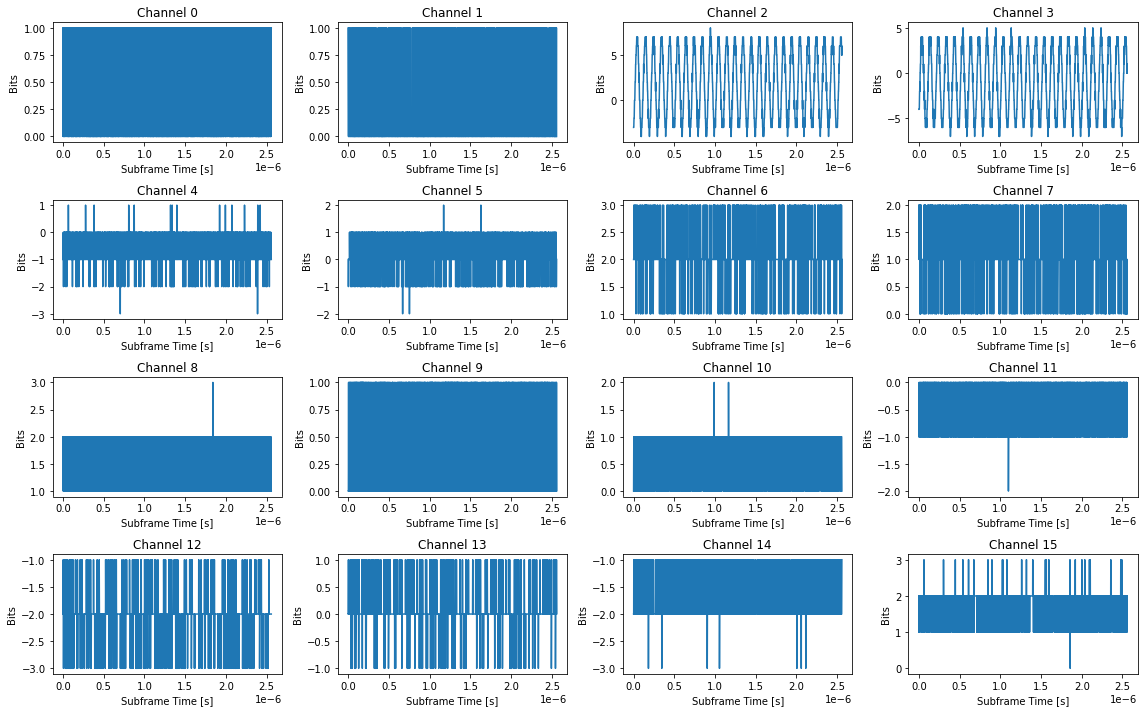

In [5]:
## Plot timeseries for each channel (for 1 subframe):
fig,ax=plt.subplots(nrows=4,ncols=4,figsize=(16,10))
for i,ind in enumerate(range(16)):
    ax.flatten()[i].plot(1.25e-9*np.arange(2048),fun_data[ind,5,:],label="".format(f['adc_input']))
    ax.flatten()[i].set_title('Channel {}'.format(ind))
    ax.flatten()[i].set_ylabel('Bits')
    ax.flatten()[i].set_xlabel('Subframe Time [s]')
    #ax.flatten()[i].set_ylim(-5,5)
plt.tight_layout()

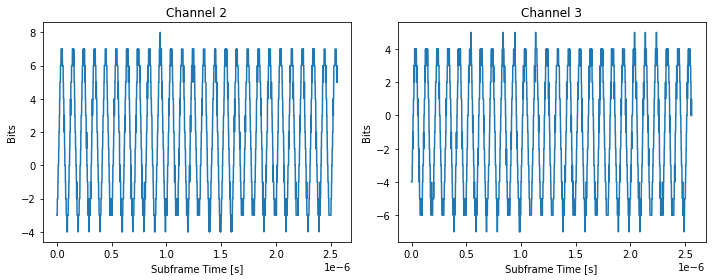

In [6]:
# Plot timeseries for Channel 2 and Channel 3 (for 1 subframe):
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

channels = [2, 3]

for i, ch in enumerate(channels):
    ax[i].plot(
        1.25e-9 * np.arange(2048),
        fun_data[ch, 5, :]
    )
    ax[i].set_title(f'Channel {ch}')
    ax[i].set_ylabel('Bits')
    ax[i].set_xlabel('Subframe Time [s]')
    # ax[i].set_ylim(-5, 5)

plt.tight_layout()


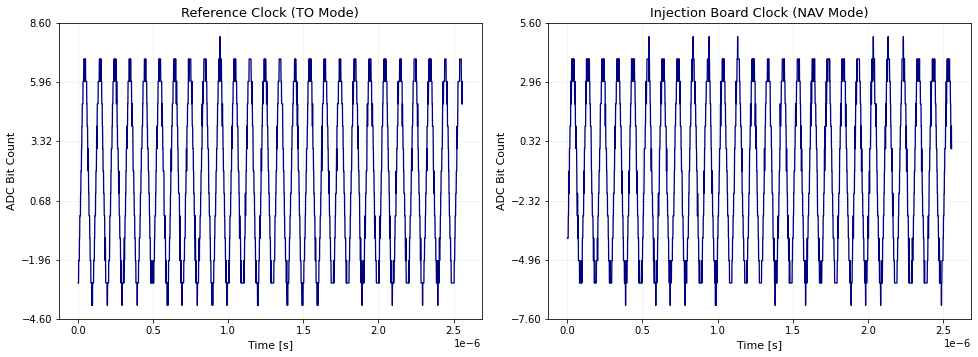

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Time axis
t = 1.25e-9 * np.arange(2048)

# Create large figure (independent axes)
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12*1.15, 4.5*1.15),
    sharey=False
)

# Channel definitions
channels = {
    2: "Reference Clock (TO Mode)",
    3: "Injection Board Clock (NAV Mode)"
}

# Plot styling
line_color = "navy"
line_width = 1.3

# Exact number of y-axis ticks you want
n_yticks = 6

# First pass: plot data
for i, (ch, title) in enumerate(channels.items()):
    ax[i].plot(
        t,
        fun_data[ch, 5, :],
        color=line_color,
        linewidth=line_width
    )
    ax[i].set_title(title, fontsize=13)
    ax[i].set_xlabel("Time [s]", fontsize=11)
    ax[i].set_ylabel("ADC Bit Count", fontsize=11)
    ax[i].tick_params(axis="both", labelsize=10)
    ax[i].grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Force drawing so limits are finalized
fig.canvas.draw()

# Second pass: enforce identical tick count & spacing
for i in range(2):
    ymin, ymax = ax[i].get_ylim()
    yticks = np.linspace(ymin, ymax, n_yticks)
    ax[i].set_yticks(yticks)

# Improve spacing for publication layout
plt.tight_layout(pad=1.5)

# Optional high-quality export
# plt.savefig("clock_timeseries.pdf", dpi=300, bbox_inches="tight")

plt.show()


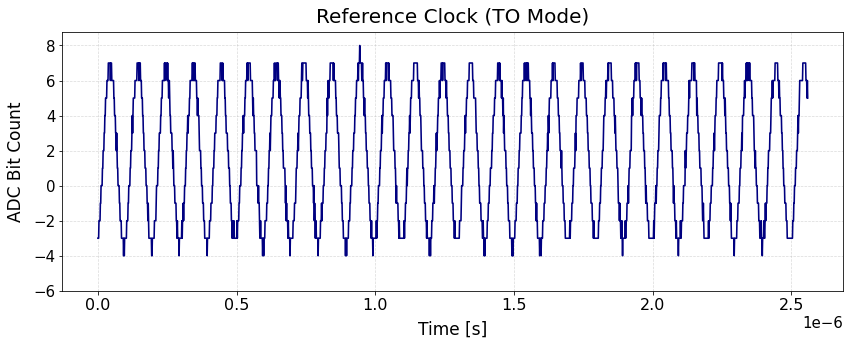

In [14]:


# Time axis
t = 1.25e-9 * np.arange(2048)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# TO mode channel
channel = 2
title = "Reference Clock (TO Mode)"

# Plot styling
line_color = "navy"
line_width = 1.6

# Plot data
ax.plot(
    t,
    fun_data[channel, 5, :],
    color=line_color,
    linewidth=line_width
)

# Titles and labels
ax.set_title(title, fontsize=20, pad=10)
ax.set_xlabel("Time [s]", fontsize=17, labelpad=8)
ax.set_ylabel("ADC Bit Count", fontsize=17, labelpad=8)

# Tick styling
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=15)

# Grid
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.45)

# ---- Autoscale first ----
ax.autoscale(axis="y")
fig.canvas.draw()

# ---- Clip to ±8 with visual headroom ----
ymin_data, ymax_data = ax.get_ylim()

ymin = max(-8, np.floor(ymin_data))
ymax = min( 8, np.ceil(ymax_data))

pad = 0.06 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)

# ---- Even-integer y ticks only ----
yticks = np.arange(ymin - (ymin % 2), ymax + 1, 2)
ax.set_yticks(yticks)

# Make x-axis scientific notation offset text larger
ax.xaxis.get_offset_text().set_size(15)

# Layout tuning
plt.tight_layout(pad=1.4)

# Optional export
# plt.savefig("clock_timeseries_TO_mode.pdf", dpi=300, bbox_inches="tight")

plt.show()


In [5]:
## Import data for the used clock channels: 
## MC: I added this show_progress flag option in rawice to remove super long print statements, optional

## FURUNO 8804 SINE WAVE (clkout) (square is running the correlator)
furuno_sine_index_1 = [0,0,2] # input to A1 = 0 [crate number, slot number, input number] 
furuno_sine_index_2 = [0,0,3]
furuno_sine_1 = analyse_maser(folder_path, furuno_sine_index_1, show_progress = False) # "maser" just means "the clock I'm looking at"
furuno_sine_2 = analyse_maser(folder_path, furuno_sine_index_2, show_progress = False ) 

clocks=[furuno_sine_1,furuno_sine_2]
titles=["furuno_sine_1","furuno_sine_2"]

/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000000
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000001
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000002
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000003
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000004
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000005
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000006
/hirax/DNS_freespace/clock_test_data/furuno_clock_tests/long_data_runs/20251208T234841Z_yale_portable_corr/raw_acq/000007
/hirax/DNS_freespace/clo

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking i

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking i

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 2] ... 
Loaded raw acq HDF5 file ... 
Checking i

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking i

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking i

Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking input [0, 0, 3] ... 
Loaded raw acq HDF5 file ... 
Checking i

In [3]:

with open("12_hour_clocks.pkl", "rb") as h:
    data = pickle.load(h)

clocks = data["clocks"]
titles = data["titles"]

furuno_sine_1 = clocks[0]
furuno_sine_2 = clocks[1]

<rawice.analyse_maser object at 0x7fd61549c820>: 1 jump(s) found → 2 segment(s)


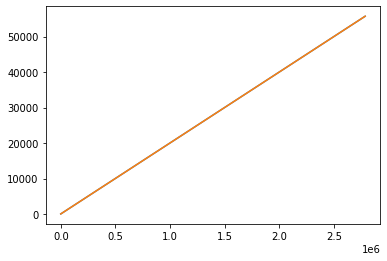

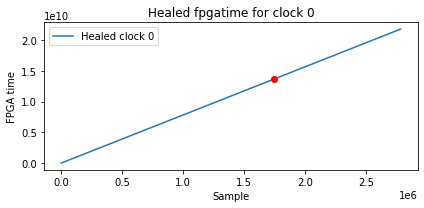

<rawice.analyse_maser object at 0x7fd6154953d0>: 1 jump(s) found → 2 segment(s)


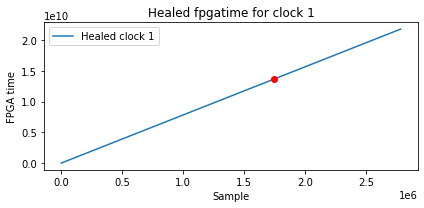


Total jumps found across all clocks: 2



In [13]:
for i,clock in enumerate(clocks):
    plt.plot(2.56e-6*clock.fpgatime[:])


# ========= HEAL FPGA CLOCKS + IDENTIFY SEGMENTS ==========

FPGA_STEP = np.int64(7812)
total_jumps = 0

for n, clock in enumerate(clocks):

    raw = np.array(clock.fpgatime, dtype=np.int64)

    # find jumps: where time increment != step
    diff = np.diff(raw) - FPGA_STEP
    jump_inds = np.where(diff != 0)[0]

    total_jumps += len(jump_inds)

    corrected = raw.copy()

    # ---- heal each jump ----
    for ind in jump_inds:
        start_val = corrected[ind]
        corrected[ind+1:] = start_val + FPGA_STEP * np.arange(1, len(corrected) - (ind+1) + 1)

    # ---- compute segments ----
    # segment boundaries in (start,end) index pairs
    boundaries = [0] + list(jump_inds + 1) + [len(corrected)]
    segments = [(boundaries[i], boundaries[i+1]) for i in range(len(boundaries)-1)]

    # attach healed data + segments to the object
    clock.fpgatime = corrected
    clock.segments = segments   # <--- NEW

    print(f"{clock}: {len(jump_inds)} jump(s) found → {len(segments)} segment(s)")

    # quick preview plot
    plt.figure(figsize=(6,3))
    plt.plot(corrected, label=f"Healed clock {n}")
    for s,e in segments[1:]:
        plt.plot([s], [corrected[s]], 'ro', markersize=6)   # mark boundaries
    plt.title(f"Healed fpgatime for clock {n}")
    plt.xlabel("Sample")
    plt.ylabel("FPGA time")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n======================================")
print(f"Total jumps found across all clocks: {total_jumps}")
print("======================================\n")


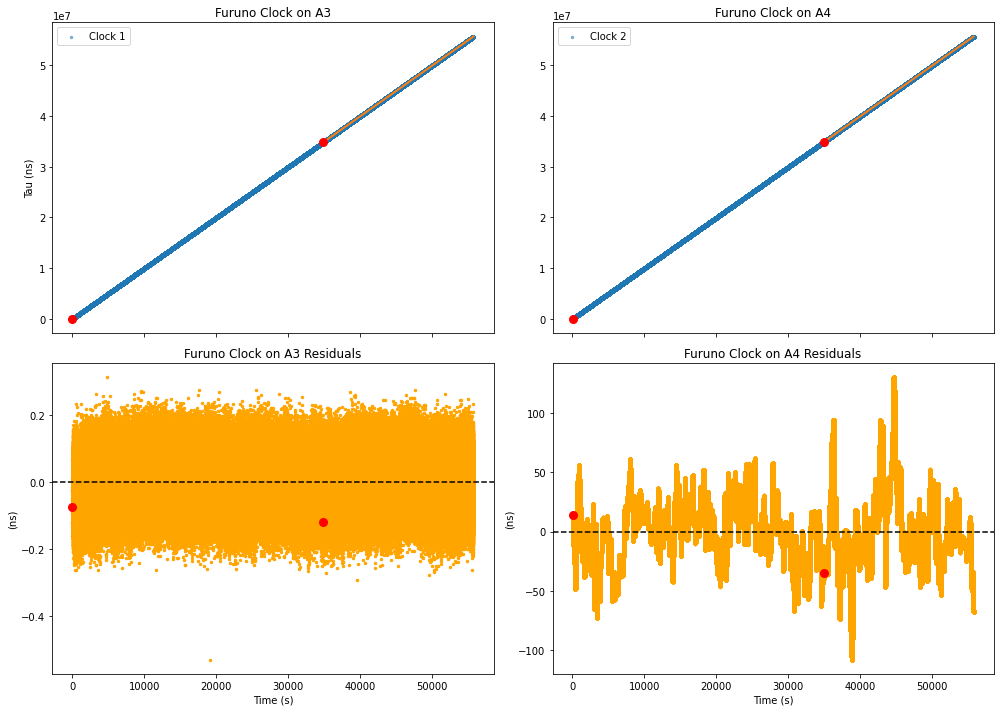

In [14]:
# ========== PER-SEGMENT LINEAR FITS + RESIDUALS ==========

from sklearn.linear_model import LinearRegression
from astropy.constants import c

def fit_segments(clock):
    """Return x,y plus per-segment model predictions and residuals."""
    x = clock.fpgatime * 2.56e-6
    y = clock.taus

    fits = []     # list of dicts for each segment: {slice, model, yfit, resid}
    
    for (s, e) in clock.segments:
        xs = x[s:e].reshape(-1,1)
        ys = y[s:e]

        model = LinearRegression().fit(xs, ys)
        yfit = model.predict(xs)
        resid = ys - yfit

        fits.append({
            "range": (s,e),
            "model": model,
            "yfit": yfit,
            "resid": resid
        })

    return x, y, fits

# -------- Fit both clocks --------
x1, y1, fits1 = fit_segments(furuno_sine_1)
x2, y2, fits2 = fit_segments(furuno_sine_2)

# -------- Plotting --------
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex='col')

# ================= CLOCK 1 =================
# Data
axes[0,0].scatter(x1, y1, s=6, label="Clock 1", alpha=0.5)

# Fits per segment
for seg in fits1:
    s,e = seg["range"]
    axes[0,0].plot(x1[s:e], seg["yfit"], '-', linewidth=2)
    axes[0,0].plot(x1[s], y1[s], 'ro', markersize=8)  # mark boundary

axes[0,0].set_title("Furuno Clock on A3")
axes[0,0].set_ylabel("Tau (ns)")
axes[0,0].legend()

# Residuals
for seg in fits1:
    s,e = seg["range"]
    axes[1,0].scatter(x1[s:e], seg["resid"], s=6, color='orange')
    axes[1,0].plot(x1[s], seg["resid"][0], 'ro', markersize=8)

axes[1,0].axhline(0, color='k', linestyle='--')
axes[1,0].set_title("Furuno Clock on A3 Residuals")
axes[1,0].set_xlabel("Time (s)")
axes[1,0].set_ylabel("(ns)")

# ================= CLOCK 2 =================
# Data
axes[0,1].scatter(x2, y2, s=6, label="Clock 2", alpha=0.5)

# Fits per segment
for seg in fits2:
    s,e = seg["range"]
    axes[0,1].plot(x2[s:e], seg["yfit"], '-', linewidth=2)
    axes[0,1].plot(x2[s], y2[s], 'ro', markersize=8)

axes[0,1].set_title("Furuno Clock on A4")
axes[0,1].legend()

# Residuals
for seg in fits2:
    s,e = seg["range"]
    axes[1,1].scatter(x2[s:e], seg["resid"], s=6, color='orange')
    axes[1,1].plot(x2[s], seg["resid"][0], 'ro', markersize=8)

axes[1,1].axhline(0, color='k', linestyle='--')
axes[1,1].set_title("Furuno Clock on A4 Residuals")
axes[1,1].set_xlabel("Time (s)")
axes[1,1].set_ylabel("(ns)")

plt.tight_layout()
plt.show()


In [15]:
# ========= CONCATENATE RESIDUALS + RENAME ARRAYS ==========

# Clock 1
x1 = furuno_sine_1.fpgatime * 2.56e-6   # match earlier usage
resid1 = np.concatenate([seg["resid"] for seg in fits1])

# Clock 2
x2 = furuno_sine_2.fpgatime * 2.56e-6
resid2 = np.concatenate([seg["resid"] for seg in fits2])

print("Residual arrays assembled:")
print(f"Clock 1: {len(resid1)} samples (segments = {len(fits1)})")
print(f"Clock 2: {len(resid2)} samples (segments = {len(fits2)})")


Residual arrays assembled:
Clock 1: 2785281 samples (segments = 2)
Clock 2: 2785281 samples (segments = 2)


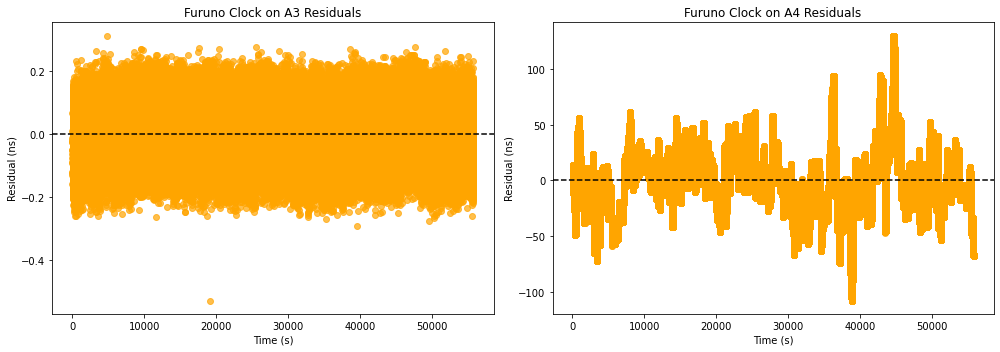

In [16]:
# Residual-only figure for both clocks (independent y-axes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clock 1 residuals
axes[0].scatter(x1, resid1, color='orange', alpha=0.7)
axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_title('Furuno Clock on A3 Residuals')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Residual (ns)')

# Clock 2 residuals
axes[1].scatter(x2, resid2, color='orange', alpha=0.7)
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_title('Furuno Clock on A4 Residuals')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual (ns)')

plt.tight_layout()
plt.show()


In [17]:
def compute_drift_jitter_segmented(x, y, segments, chunk_width=1.0, show_plots=False):
    """
    Computes drift, jitter, and adjusted drift PER SEGMENT.
    Segment results are concatenated at the end and plotted together.

    Parameters
    ----------
    x : array
        Full FPGA time array (seconds).
    y : array
        Residuals (in ns).
    segments : list of (start,end) index pairs
        Segments from clock.segments.
    chunk_width : float
        Chunk width in seconds.
    show_plots : bool
        Display plots if True.

    Returns
    -------
    dict with all plotting arrays concatenated across segments
    """

    all_x_groups = []
    all_y_groups = []
    all_chunk_means = []
    all_chunk_stds = []
    all_adj_chunk_means = []
    
    # NEW: holds the representative timestamp for each chunk
    all_chunk_times = []

    # ---------- LOOP OVER SEGMENTS ----------
    for seg_index, (s, e) in enumerate(segments):

        xs = x[s:e]
        ys = y[s:e]

        # reference time for THIS segment
        t0 = xs[0]
        elapsed = xs - t0

        # ---------------------------------
        # 1. Chunk assignment *within segment*
        # ---------------------------------
        group_ids = np.floor(elapsed / chunk_width).astype(int)
        groups = np.unique(group_ids)

        x_groups = [xs[group_ids == g] for g in groups]
        y_groups = [ys[group_ids == g] for g in groups]

        # Representative timestamp for each chunk (center of chunk)
        # NEW:
        chunk_times = t0 + (groups * chunk_width + chunk_width / 2.0)

        # Compute drift + jitter within segment
        per_chunk_means = np.array([np.mean(g) for g in y_groups])
        per_chunk_stds  = np.array([np.std(g)  for g in y_groups])

        # ---------------------------------
        # 2. 1-second detrended drift (within segment)
        # ---------------------------------
        one_sec_ids = np.floor(elapsed / 1.0).astype(int)
        one_sec_groups = np.unique(one_sec_ids)

        one_sec_means = {
            g: np.mean(ys[one_sec_ids == g])
            for g in one_sec_groups
        }

        chunk_parent_1s_group = np.floor((groups * chunk_width) / 1.0).astype(int)

        adjusted_chunk_means = np.array([
            per_chunk_means[i] - one_sec_means[chunk_parent_1s_group[i]]
            for i in range(len(per_chunk_means))
        ])

        # ---------- STORE RESULTS ----------
        all_x_groups.extend(x_groups)
        all_y_groups.extend(y_groups)
        all_chunk_means.extend(per_chunk_means)
        all_chunk_stds.extend(per_chunk_stds)
        all_adj_chunk_means.extend(adjusted_chunk_means)
        
        # NEW: store chunk times
        all_chunk_times.extend(chunk_times)

    # ======= CONCAT RESULTS ACROSS SEGMENTS =======
    all_chunk_means = np.array(all_chunk_means)
    all_chunk_stds = np.array(all_chunk_stds)
    all_adj_chunk_means = np.array(all_adj_chunk_means)
    all_chunk_times = np.array(all_chunk_times)   # NEW

    # Global drift/jitter = computed across all per-chunk values
    drift = np.std(all_chunk_means)
    jitter = np.mean(all_chunk_stds)
    adjusted_drift = np.std(all_adj_chunk_means)

    print(f"Total Chunks: {len(all_x_groups)}")
    print(f"Global Drift: {drift*1e-9:.3e} s")
    print(f"Global Jitter: {jitter*1e-9:.3e} s")
    print(f"Adjusted Drift (1s detrended): {adjusted_drift*1e-9:.3e} s")

    # ---------------------------------
    # PLOTTING (all segments combined)
    # ---------------------------------
    if show_plots:

        # Raw data
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, s=5)
        plt.xlabel("Time (s)")
        plt.ylabel("Residuals (ns)")
        plt.title("Tau Residuals (All Segments)")
        plt.show()

        # Per-chunk means
        plt.figure(figsize=(10, 6))
        plt.scatter(all_chunk_times, all_chunk_means, s=25)   # UPDATED: use time axis
        plt.axhline(+drift, color='red', linestyle='--')
        plt.axhline(-drift, color='red', linestyle='--')
        plt.xlabel("Time (s)")
        plt.ylabel("ns")
        plt.title(f"Per-Chunk Means — Global Drift = {drift*1e-9:.3e} s")
        plt.show()

        # Per-chunk stds
        plt.figure(figsize=(10, 6))
        plt.scatter(all_chunk_times, all_chunk_stds, s=25)    # UPDATED: use time axis
        plt.axhline(jitter, color='red', linestyle='--')
        plt.xlabel("Time (s)")
        plt.ylabel("ns")
        plt.title(f"Per-Chunk Standard Deviations — Global Jitter = {jitter*1e-9:.3e} s")
        plt.show()

        # Adjusted per-chunk means
        plt.figure(figsize=(10, 6))
        plt.scatter(all_chunk_times, all_adj_chunk_means, s=25)   # UPDATED: use time axis
        plt.axhline(+adjusted_drift, color='red', linestyle='--')
        plt.axhline(-adjusted_drift, color='red', linestyle='--')
        plt.xlabel("Time (s)")
        plt.ylabel("ns (1s-detrended)")
        plt.title(f"Adjusted Means — Adjusted Drift = {adjusted_drift*1e-9:.3e} s")
        plt.show()

    # ---------------------------------
    # RETURN EVERYTHING
    # ---------------------------------
    return {
        "x_groups": all_x_groups,
        "y_groups": all_y_groups,
        "chunk_times": all_chunk_times,               # NEW
        "per_chunk_means": all_chunk_means,
        "per_chunk_stds": all_chunk_stds,
        "drift": drift,
        "jitter": jitter,
        "adjusted_chunk_means": all_adj_chunk_means,
        "adjusted_drift": adjusted_drift,
    }


Total Chunks: 327714
Global Drift: 2.545e-11 s
Global Jitter: 5.101e-11 s
Adjusted Drift (1s detrended): 1.781e-11 s


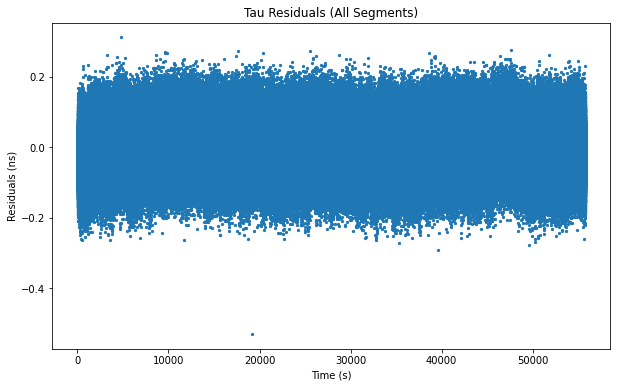

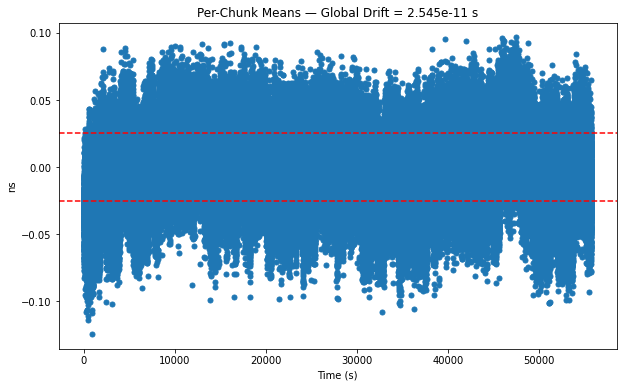

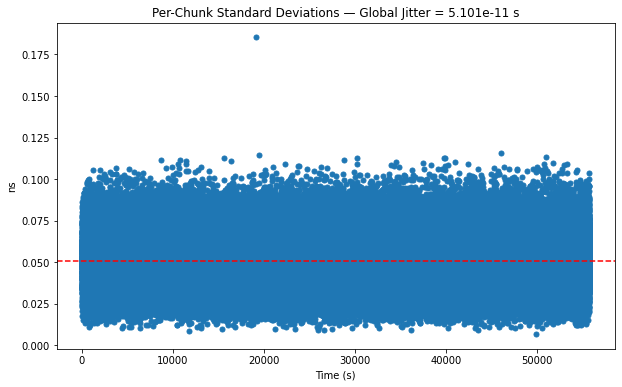

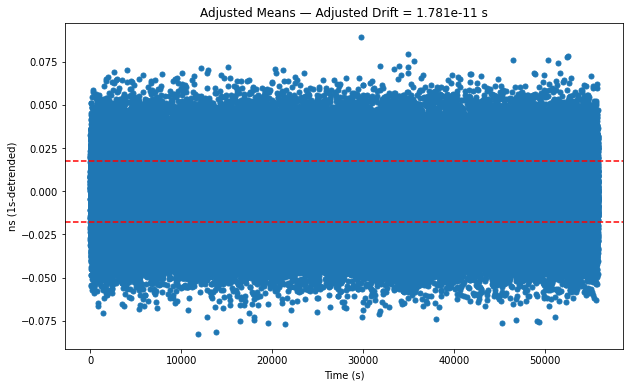

In [23]:
results1 = compute_drift_jitter_segmented(
    x1, resid1, furuno_sine_1.segments,
    chunk_width=0.169972 , show_plots=True
)


Total Chunks: 327714
Global Drift: 2.908e-08 s
Global Jitter: 5.275e-11 s
Adjusted Drift (1s detrended): 1.053e-10 s


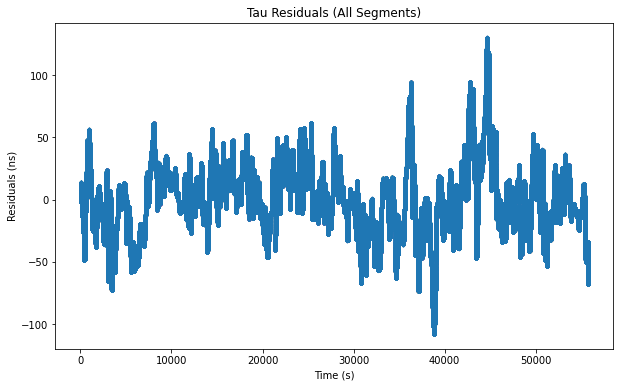

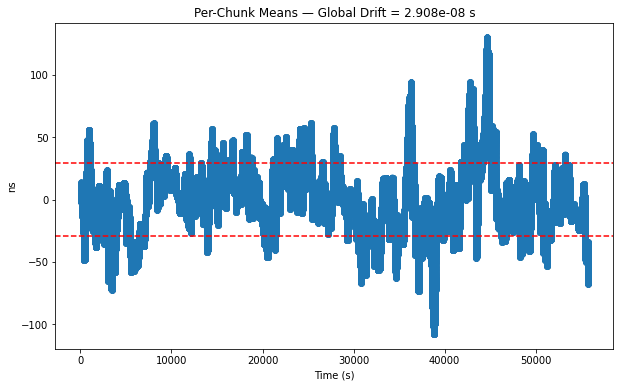

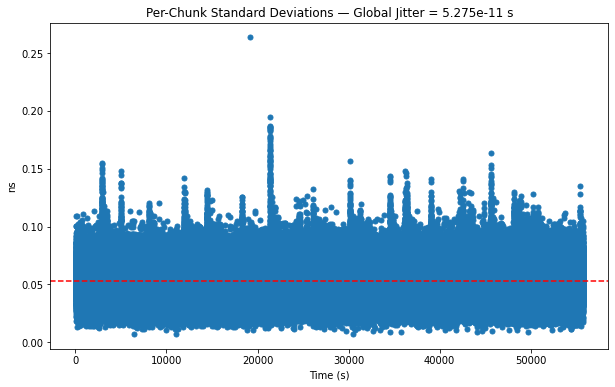

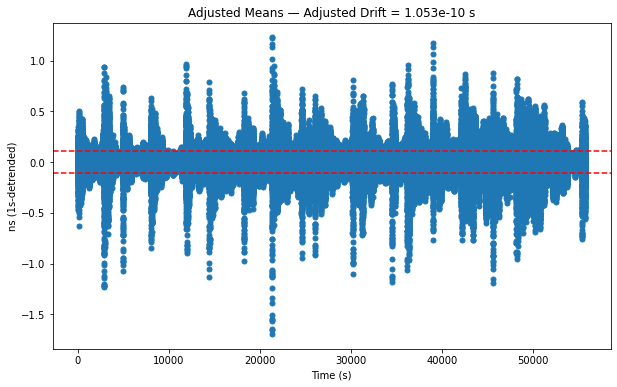

In [24]:
results2 = compute_drift_jitter_segmented(
    x2, resid2, furuno_sine_2.segments,
    chunk_width=0.169972, show_plots=True
)

In [26]:
# Save both results to disk
with open("12_hour_drift_jitter_results.pkl", "wb") as k:
    pickle.dump({"results1": results1, "results2": results2}, k)

print("Saved results1 and results2 to 12_hour_drift_jitter_results.pkl")


Saved results1 and results2 to 12_hour_drift_jitter_results.pkl


In [1]:
import pickle

# Load the results from disk
with open("12_hour_drift_jitter_results.pkl", "rb") as k:
    data2 = pickle.load(k)

results1 = data2["results1"]
results2 = data2["results2"]

print("Loaded results1 and results2 from 12_hour_drift_jitter_results.pkl")

Loaded results1 and results2 from 12_hour_drift_jitter_results.pkl


<ipython-input-36-05a14e1761a9>:170: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.10, right=0.83, bottom=0.12, top=0.92)


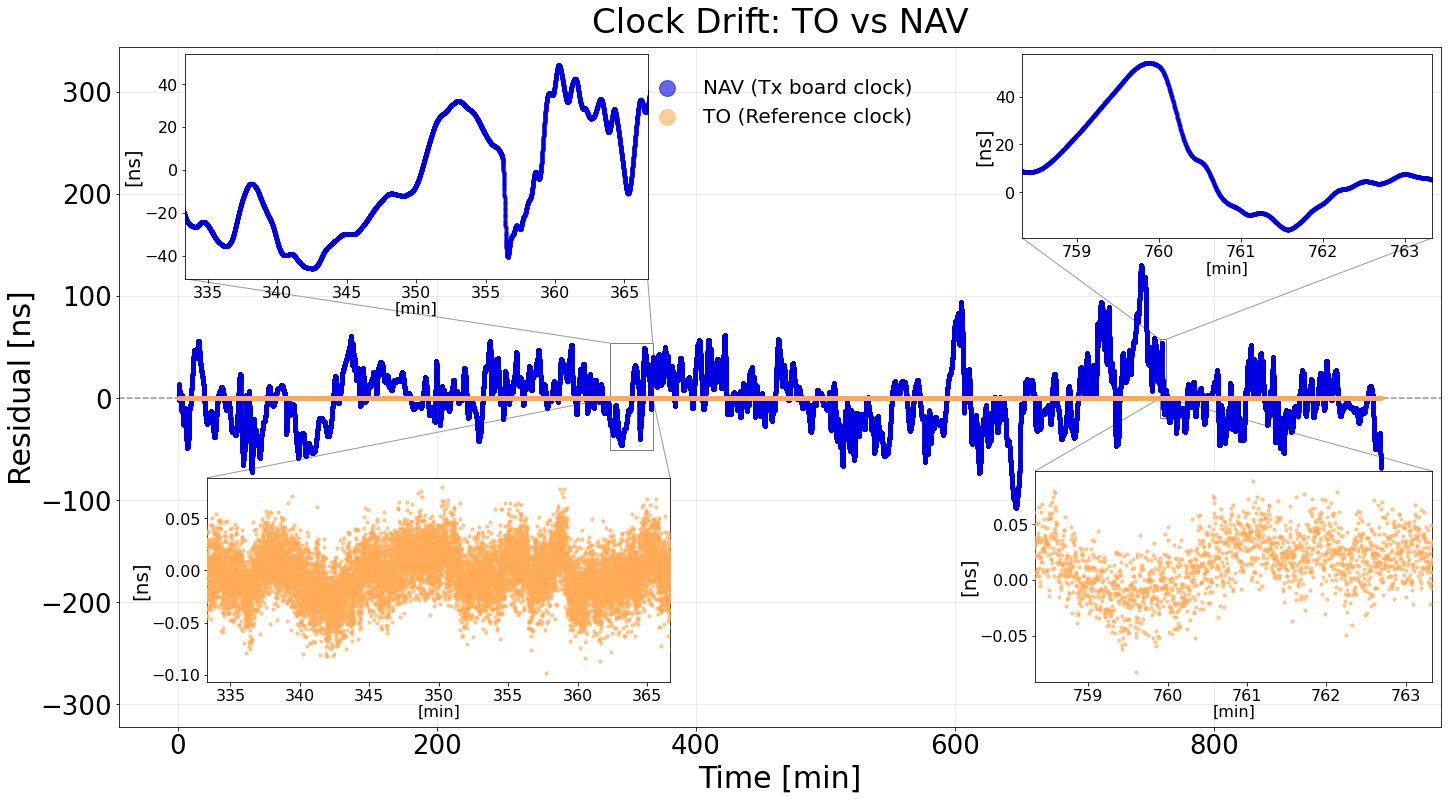

<ipython-input-36-05a14e1761a9>:209: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.10, right=0.83, bottom=0.12, top=0.92)


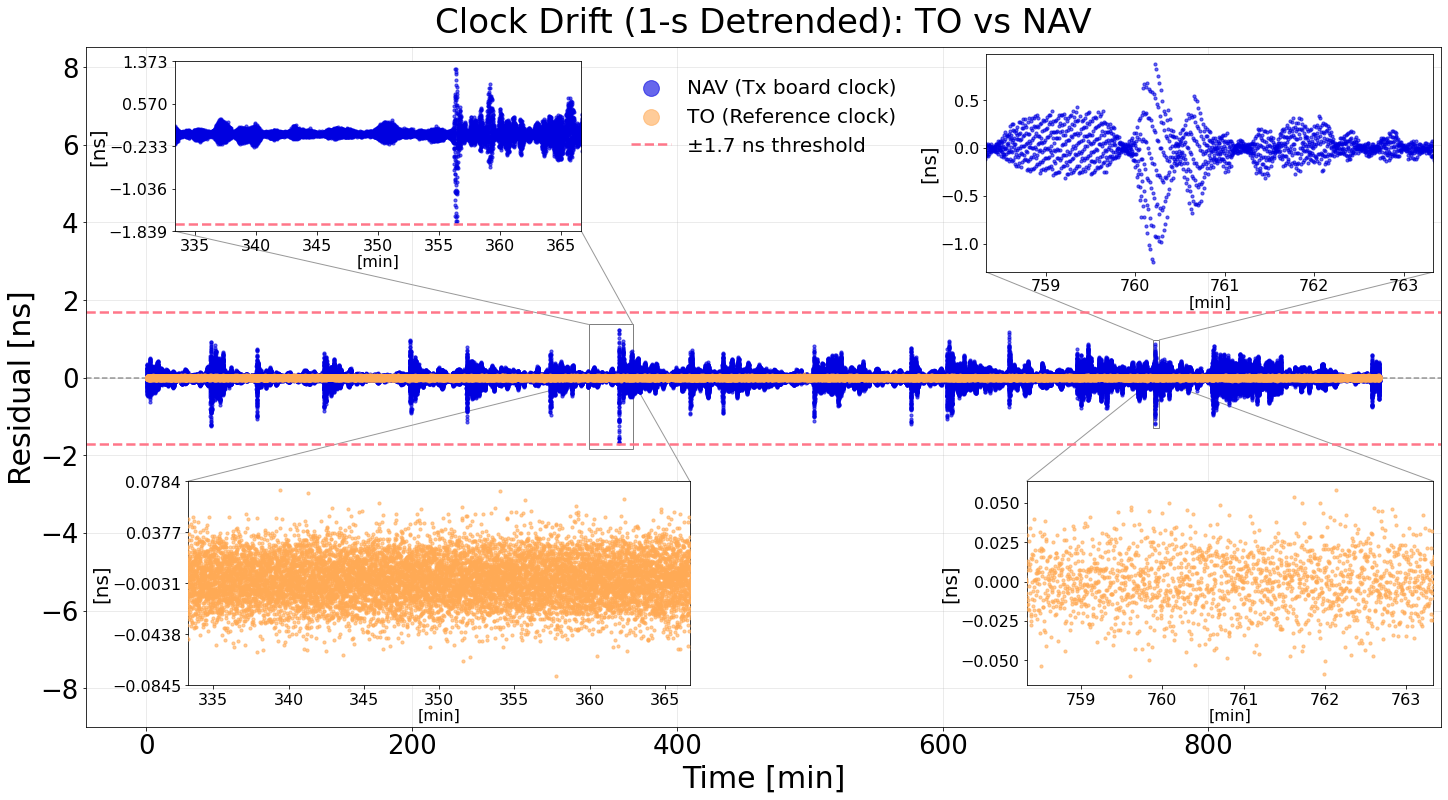

In [36]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import ConnectionPatch


plt.rcParams.update({
    "axes.titlesize": 34,
    "axes.labelsize": 30,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 20,
})

# -------------------------
# Data
# -------------------------
idx1_s = np.asarray(results1["chunk_times"], dtype=float)  # TO seconds
idx2_s = np.asarray(results2["chunk_times"], dtype=float)  # NAV seconds

idx1_m = idx1_s / 60.0
idx2_m = idx2_s / 60.0

zoom1_start_s, zoom1_stop_s = 20000, 22000
zoom2_start_s, zoom2_stop_s = 45500, 45800
zoom1_start_m, zoom1_stop_m = zoom1_start_s / 60.0, zoom1_stop_s / 60.0
zoom2_start_m, zoom2_stop_m = zoom2_start_s / 60.0, zoom2_stop_s / 60.0

cmap = plt.get_cmap("gnuplot2")
to_color  = cmap(0.75)
nav_color = cmap(0.22)
threshold_color = cmap(0.65)

nav_scatter = dict(alpha=0.6, s=10, color=nav_color, label="NAV (Tx board clock)", zorder=2)
to_scatter  = dict(alpha=0.6, s=10, color=to_color,  label="TO (Reference clock)", zorder=3)

line_pos = 1.7  # ns


# --------------------------------------------------
# Inset helper
# --------------------------------------------------
def add_inset_single(
    ax,
    x_m, y, kw,
    x_start_m, x_stop_m,
    *,
    loc="upper left",
    width="19%",
    height="20%",
    borderpad=2.8,
    corner="tl",  # "tl" means use TOP corners on inset; anything else -> BOTTOM corners 
    include_threshold=False,
    detailed_yticks=False,
    ylabel="[ns]",
    xlabel="min",
    bbox_to_anchor=None,
    bbox_transform=None,
):
    axins = inset_axes(
        ax,
        width=width,
        height=height,
        loc=loc,
        borderpad=borderpad,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=bbox_transform,
    )

    kwi = dict(kw); kwi.pop("label", None)
    axins.scatter(x_m, y, **kwi)
    axins.set_xlim(x_start_m, x_stop_m)

    mask = (x_m >= x_start_m) & (x_m <= x_stop_m)
    if np.any(mask):
        ywin = np.asarray(y)[mask]
        ymin, ymax = np.min(ywin), np.max(ywin)

        shrink_factor = 1.1
        y_center = 0.5 * (ymax + ymin)
        y_half = 0.5 * (ymax - ymin) * shrink_factor
        if y_half == 0:
            y_half = 1.0
        axins.set_ylim(y_center - y_half, y_center + y_half)

        if detailed_yticks:
            axins.set_yticks(np.linspace(y_center - y_half, y_center + y_half, 5))

    if include_threshold:
        axins.axhline(line_pos,  color=threshold_color, linestyle="--", linewidth=2.5)
        axins.axhline(-line_pos, color=threshold_color, linestyle="--", linewidth=2.5)

    axins.tick_params(labelsize=16)
    axins.set_ylabel(ylabel, fontsize=20, labelpad=1)
    axins.set_xlabel("[min]", fontsize=16, labelpad=1)

    # -------------------------
    # NEW CONNECTOR BEHAVIOR:
    #   - inset attaches to TOP corners if corner=="tl" else BOTTOM corners 
    #   - main rectangle attaches to OPPOSITE (top<->bottom)
    # -------------------------

    # Define rectangle corners on the MAIN axes in *data coords*
    # The rectangle corresponds to inset x/y limits.
    x0, x1 = axins.get_xlim()
    y0, y1 = axins.get_ylim()

    # Draw rectangle (use mark_inset just to generate the patch cleanly; then hide its connectors)
    pp, p1, p2 = mark_inset(ax, axins, loc1=1, loc2=2, fc="none", ec="0.5")
    p1.set_visible(False)
    p2.set_visible(False)

    # Choose which corners on inset frame (in axes-fraction coords for true "frame" corners)
    inset_top_left     = (0, 1)
    inset_top_right    = (1, 1)
    inset_bottom_left  = (0, 0)
    inset_bottom_right = (1, 0)

    # Choose which corners on main rectangle (in main data coords)
    main_top_left     = (x0, y1)
    main_top_right    = (x1, y1)
    main_bottom_left  = (x0, y0)
    main_bottom_right = (x1, y0)

    # If inset connectors touch TOP corners, connect to BOTTOM corners on main rectangle, and vice versa
    if corner == "tl":  # inset TOP
        main_A1, main_A2 = main_bottom_left, main_bottom_right
        inset_B1, inset_B2 = inset_top_left, inset_top_right
    else:               # inset BOTTOM
        main_A1, main_A2 = main_top_left, main_top_right
        inset_B1, inset_B2 = inset_bottom_left, inset_bottom_right

    con1 = ConnectionPatch(
        xyA=main_A1, coordsA=ax.transData,
        xyB=inset_B1, coordsB=axins.transAxes,
        color="0.6", lw=1.0
    )
    con2 = ConnectionPatch(
        xyA=main_A2, coordsA=ax.transData,
        xyB=inset_B2, coordsB=axins.transAxes,
        color="0.6", lw=1.0
    )
    ax.add_artist(con1)
    ax.add_artist(con2)


def set_ylim_from_both(ax, y1, y2, margin_factor=1.0):
    y_all = np.concatenate([np.asarray(y1), np.asarray(y2)])
    ymin, ymax = np.min(y_all), np.max(y_all)
    y_margin = margin_factor * (ymax - ymin) if ymax > ymin else 1.0
    ax.set_ylim(ymin - y_margin, ymax + y_margin)


def place_legend_top_center(ax):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.98), frameon=False, markerscale=5)


# ============================================================
# (1) RAW combined
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(20, 11), constrained_layout=True)
fig.subplots_adjust(left=0.10, right=0.83, bottom=0.12, top=0.92)

ax.scatter(idx2_m, results2["per_chunk_means"], **nav_scatter)
ax.scatter(idx1_m, results1["per_chunk_means"], **to_scatter)
ax.axhline(0, color="k", linestyle="--", alpha=0.4)

ax.set_title("Clock Drift: TO vs NAV", pad=14)
ax.set_xlabel("Time [min]")
ax.set_ylabel("Residual [ns]")
ax.grid(alpha=0.3)

set_ylim_from_both(ax, results1["per_chunk_means"], results2["per_chunk_means"], margin_factor=0.9)

add_inset_single(ax, idx2_m, results2["per_chunk_means"], nav_scatter, zoom1_start_m, zoom1_stop_m,
                 loc="upper left", height="33%", width="35%", corner="ll", borderpad=3.1,
                 bbox_to_anchor=(.003, 0.08, 1.0, 1.0), bbox_transform=ax.transAxes)

add_inset_single(ax, idx1_m, results1["per_chunk_means"], to_scatter, zoom1_start_m, zoom1_stop_m,
                 bbox_to_anchor=(.02, -0.025, 1.0, 1.0), height="30%", width="35%",
                 loc="lower left", corner="tl", borderpad=3.1, bbox_transform=ax.transAxes)

add_inset_single(ax, idx2_m, results2["per_chunk_means"], nav_scatter, zoom2_start_m, zoom2_stop_m,
                 loc="upper right", height="27%", width="31%", borderpad=3.1, corner="ll",
                 bbox_to_anchor=(0.04, 0.08, 1.0, 1.0),
                 bbox_transform=ax.transAxes)

add_inset_single(ax, idx1_m, results1["per_chunk_means"], to_scatter, zoom2_start_m, zoom2_stop_m,
                 height="31%", width="30%", loc="lower right", corner="tl", borderpad=3.1,
                 bbox_to_anchor=(0.04, -0.025, 1.0, 1.0),
                 bbox_transform=ax.transAxes)

place_legend_top_center(ax)
plt.show()


# ============================================================
# (2) DETRENDED combined  ← MATCHES ABOVE GEOMETRY
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(20, 11), constrained_layout=True)
fig.subplots_adjust(left=0.10, right=0.83, bottom=0.12, top=0.92)

ax.scatter(idx2_m, results2["adjusted_chunk_means"], **nav_scatter)
ax.scatter(idx1_m, results1["adjusted_chunk_means"], **to_scatter)

ax.axhline(0, color="k", linestyle="--", alpha=0.4)
ax.axhline(line_pos,  color=threshold_color, linestyle="--", linewidth=2.5, label="±1.7 ns threshold")
ax.axhline(-line_pos, color=threshold_color, linestyle="--", linewidth=2.5)

ax.set_title("Clock Drift (1-s Detrended): TO vs NAV", pad=14)
ax.set_xlabel("Time [min]")
ax.set_ylabel("Residual [ns]")
ax.grid(alpha=0.3)

set_ylim_from_both(ax, results1["adjusted_chunk_means"], results2["adjusted_chunk_means"], margin_factor=2.5)

add_inset_single(ax, idx2_m, results2["adjusted_chunk_means"], nav_scatter, zoom1_start_m, zoom1_stop_m,
                 loc="upper left", height="25%", width="30%", corner="ll", borderpad=3.1,
                 include_threshold=True, detailed_yticks=True,
                 bbox_to_anchor=(0.02, 0.07, 1.0, 1.0), bbox_transform=ax.transAxes)

add_inset_single(ax, idx1_m, results1["adjusted_chunk_means"], to_scatter, zoom1_start_m, zoom1_stop_m,
                 loc="lower left", height="30%", width="37%", corner="tl", borderpad=3.1,
                 include_threshold=True, detailed_yticks=True,
                 bbox_to_anchor=(.03, -0.03, 1.0, 1.0), bbox_transform=ax.transAxes)

add_inset_single(ax, idx2_m, results2["adjusted_chunk_means"], nav_scatter, zoom2_start_m, zoom2_stop_m,
                 loc="upper right", height="32%", width="33%", corner="ll", borderpad=3.1,
                 include_threshold=True,
                 bbox_to_anchor=(0.04, 0.08, 1.0, 1.0), bbox_transform=ax.transAxes)

add_inset_single(ax, idx1_m, results1["adjusted_chunk_means"], to_scatter, zoom2_start_m, zoom2_stop_m,
                 loc="lower right", height="30%", width="30%", corner="tl", borderpad=3.1,
                 include_threshold=True,
                 bbox_to_anchor=(0.04, -0.03, 1.0, 1.0), bbox_transform=ax.transAxes)

place_legend_top_center(ax)
plt.show()


--------------

<br><br><br><br><br><br>

# Shorter Data Runs


<br><br><br><br><br><br>

---------------

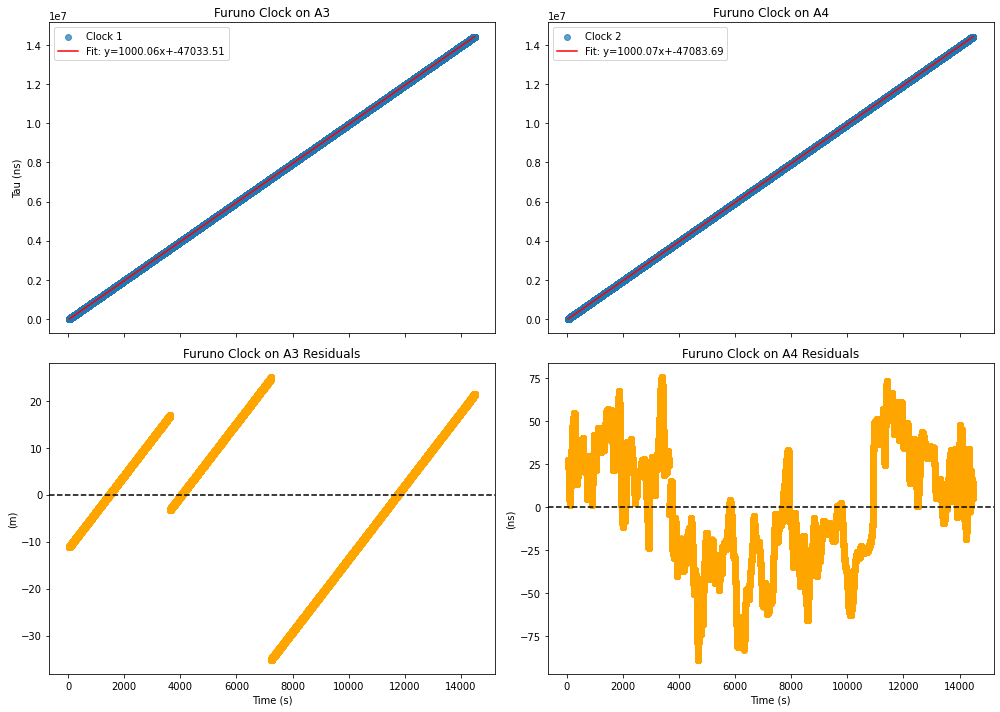

In [56]:
#Now we can get the tau slope for each clock, should both look nice and linear

#Here we'll plot the taus with a fit and residuals for the whole timestream of each one: 

from sklearn.linear_model import LinearRegression
from astropy.constants import c

x1 =furuno_sine_1.fpgatime*2.56e-6
y1 = furuno_sine_1.taus

x2 = furuno_sine_2.fpgatime*2.56e-6
y2 = furuno_sine_2.taus

# Fit linear regressions
model1 = LinearRegression().fit(x1.reshape(-1, 1), y1)
model2 = LinearRegression().fit(x2.reshape(-1, 1), y2)

# Predicted values
y1_fit = model1.predict(x1.reshape(-1, 1))
y2_fit = model2.predict(x2.reshape(-1, 1))

# Residuals
resid1 = y1 - y1_fit
resid2 = y2 - y2_fit

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')

# Dataset 1: data + fit
axes[0, 0].scatter(x1, y1, label='Clock 1', alpha=0.7)
axes[0, 0].plot(x1, y1_fit, 'r-', label=f'Fit: y={model1.coef_[0]:.2f}x+{model1.intercept_:.2f}')
axes[0, 0].set_ylabel('Tau (ns)')
axes[0, 0].legend()
axes[0, 0].set_title('Furuno Clock on A3')

# Dataset 1: residuals
axes[1, 0].scatter(x1, resid1, color='orange', alpha=0.7)
axes[1, 0].axhline(0, color='k', linestyle='--')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('(m)')
axes[1, 0].set_title('Furuno Clock on A3 Residuals')

# Dataset 2: data + fit
axes[0, 1].scatter(x2, y2, label='Clock 2', alpha=0.7)
axes[0, 1].plot(x2, y2_fit, 'r-', label=f'Fit: y={model2.coef_[0]:.2f}x+{model2.intercept_:.2f}')
axes[0, 1].legend()
axes[0, 1].set_title('Furuno Clock on A4')

# Dataset 2: residuals
axes[1, 1].scatter(x2, resid2, color='orange', alpha=0.7)
axes[1, 1].axhline(0, color='k', linestyle='--')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('(ns)')
axes[1, 1].set_title('Furuno Clock on A4 Residuals')

plt.tight_layout()
plt.show()



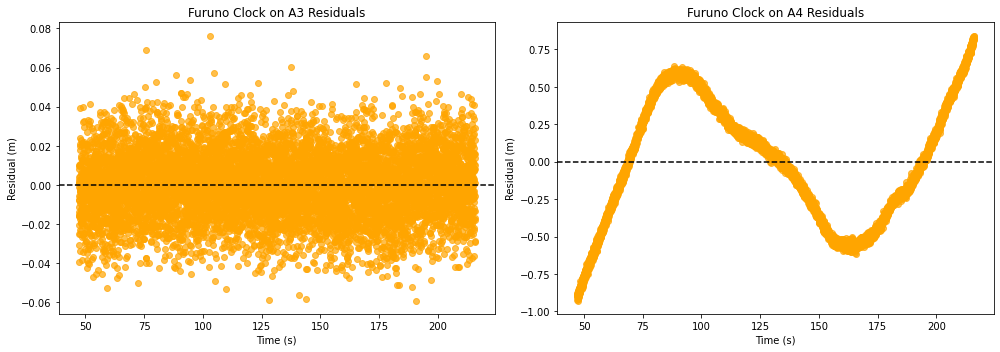

In [7]:
# Residual-only figure for both clocks (independent y-axes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clock 1 residuals
axes[0].scatter(x1, resid1 * 1e-9 * c, color='orange', alpha=0.7)
axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_title('Furuno Clock on A3 Residuals')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Residual (m)')

# Clock 2 residuals
axes[1].scatter(x2, resid2 * 1e-9 * c, color='orange', alpha=0.7)
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_title('Furuno Clock on A4 Residuals')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual (m)')

plt.tight_layout()
plt.show()


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def compute_drift_jitter(x, y, chunk_width=1.0, show_plots=False):
    """
    Computes drift, jitter, and a 1-second–detrended drift metric.
    
    New options:
    - show_plots: optional flag to display plots
    - All data arrays used for plotting are returned in the output dictionary
    """

    # Reference time
    t0 = x[0]
    elapsed = x - t0

    # ---------------------------------
    # 1. User-chosen chunk width
    # ---------------------------------
    group_ids = np.floor(elapsed / chunk_width).astype(int)
    groups = np.unique(group_ids)

    x_groups = [x[group_ids == g] for g in groups]
    y_groups = [y[group_ids == g] for g in groups]

    print(f"Total Chunks Sampled: {len(x_groups)}")
    print(f"Samples per Chunk (first chunk): {len(x_groups[0])}")

    # Drift = std of per-chunk means
    per_chunk_means = np.array([np.mean(g) for g in y_groups])
    drift = np.std(per_chunk_means)

    # Jitter = mean of per-chunk stds
    per_chunk_stds = np.array([np.std(g) for g in y_groups])
    jitter = np.mean(per_chunk_stds)

    print("Drift [Std of means] (s):", drift * 1e-9)
    print("Jitter [Mean of stds] (s):", jitter * 1e-9)

    # ---------------------------------
    # 2. 1-second detrended drift
    # ---------------------------------
    one_sec_group_ids = np.floor(elapsed / 1.0).astype(int)
    one_sec_groups = np.unique(one_sec_group_ids)

    one_sec_means = {
        g: np.mean(y[one_sec_group_ids == g])
        for g in one_sec_groups
    }

    # Map each chunk to its parent 1-second group
    chunk_parent_1s_group = np.floor((groups * chunk_width) / 1.0).astype(int)

    adjusted_chunk_means = np.array([
        per_chunk_means[i] - one_sec_means[chunk_parent_1s_group[i]]
        for i in range(len(per_chunk_means))
    ])

    adjusted_drift = np.std(adjusted_chunk_means)
    print("Adjusted Drift (1s-detrended) (s):", adjusted_drift * 1e-9)

    # ---------------------------------
    # Plotting
    # ---------------------------------
    if show_plots:

        # Raw residual plot
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, s=10)
        plt.xlabel("Time (s)")
        plt.ylabel("Residuals (ns)")
        plt.title("Tau Residuals (Raw Data)")

        # Per-chunk means
        plt.figure(figsize=(10, 6))
        chunk_idx = np.arange(len(per_chunk_means))
        plt.scatter(chunk_idx, per_chunk_means, s=25)
        plt.axhline(+drift, color='red', linestyle='--', linewidth=1)
        plt.axhline(-drift, color='red', linestyle='--', linewidth=1)
        plt.xlabel("Interval Count")
        plt.ylabel("ns")
        plt.title(f"Per-Chunk Means — Drift = {drift*1e-9:.3e} s")

        # Per-chunk stds
        plt.figure(figsize=(10, 6))
        std_idx = np.arange(len(per_chunk_stds))
        plt.scatter(std_idx, per_chunk_stds, s=25)
        plt.axhline(jitter, color='red', linestyle='--', linewidth=1)
        plt.xlabel("Interval Count")
        plt.ylabel("ns")
        plt.title(f"Per-Chunk Standard Deviations — Jitter = {jitter*1e-9:.3e} s")

        # Adjusted per-chunk means
        plt.figure(figsize=(10, 6))
        adj_idx = np.arange(len(adjusted_chunk_means))
        plt.scatter(adj_idx, adjusted_chunk_means, s=25)
        plt.axhline(+adjusted_drift, color='red', linestyle='--', linewidth=1)
        plt.axhline(-adjusted_drift, color='red', linestyle='--', linewidth=1)
        plt.xlabel("Interval Count")
        plt.ylabel("ns (1-second-detrended)")
        plt.title(
            f"Adjusted Per-Chunk Means — Adjusted Drift = {adjusted_drift*1e-9:.3e} s"
        )

    # ---------------------------------
    # Return everything used for plots
    # ---------------------------------
    return {
        "x_groups": x_groups,
        "y_groups": y_groups,
        "per_chunk_means": per_chunk_means,
        "per_chunk_stds": per_chunk_stds,
        "per_chunk_mean_idx": np.arange(len(per_chunk_means)),
        "per_chunk_std_idx": np.arange(len(per_chunk_stds)),
        "drift": drift,
        "jitter": jitter,
        "one_sec_means": one_sec_means,
        "adjusted_chunk_means": adjusted_chunk_means,
        "adjusted_chunk_mean_idx": np.arange(len(adjusted_chunk_means)),
        "adjusted_drift": adjusted_drift,
    }


In [10]:
results1 = compute_drift_jitter(x1, resid1, chunk_width=0.16777216, show_plots = False) #chunk_width=0.16777216

Total Chunks Sampled: 1007
Samples per Chunk (first chunk): 9
Drift [Std of means] (s): 1.994219562655873e-11
Jitter [Mean of stds] (s): 5.0204036516280994e-11
Adjusted Drift (1s-detrended) (s): 1.743405274152253e-11


In [11]:
results2 = compute_drift_jitter(x2, resid2, chunk_width=0.16777216, show_plots=False) #chunk_width=0.16777216

Total Chunks Sampled: 1007
Samples per Chunk (first chunk): 9
Drift [Std of means] (s): 1.3567294671962352e-09
Jitter [Mean of stds] (s): 5.05811801571308e-11
Adjusted Drift (1s-detrended) (s): 3.228969210762006e-11


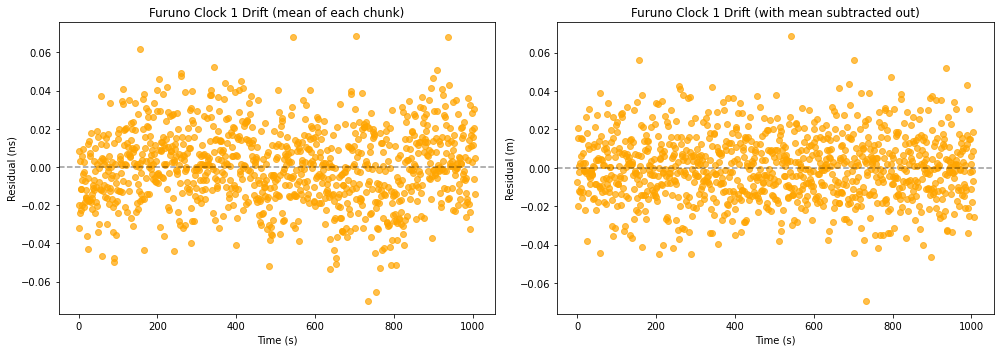

In [18]:
# Residual-only figure for both clocks (independent y-axes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clock 1 residuals
axes[0].scatter(results1['adjusted_chunk_mean_idx'], results1['per_chunk_means'], color='orange', alpha=0.7)
axes[0].axhline(0, color='k', linestyle='--',alpha=0.4)
axes[0].set_title('Furuno Clock 1 Drift (mean of each chunk)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Residual (ns)')

# Clock 2 residuals
axes[1].scatter(results1['adjusted_chunk_mean_idx'], results1['adjusted_chunk_means'], color='orange', alpha=0.7)
axes[1].axhline(0, color='k', linestyle='--',alpha=0.4)
axes[1].set_title('Furuno Clock 1 Drift (with mean subtracted out)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual (m)')

plt.tight_layout()
plt.show()


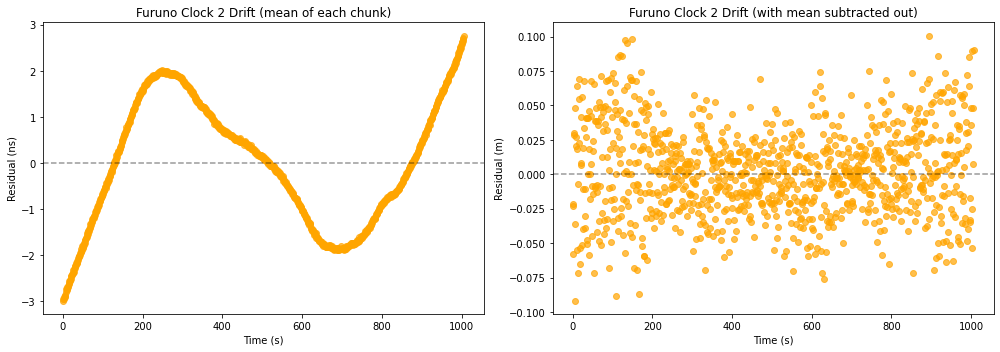

In [19]:
# Residual-only figure for both clocks (independent y-axes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clock 1 residuals
axes[0].scatter(results2['adjusted_chunk_mean_idx'], results2['per_chunk_means'], color='orange', alpha=0.7)
axes[0].axhline(0, color='k', linestyle='--',alpha=0.4)
axes[0].set_title('Furuno Clock 2 Drift (mean of each chunk)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Residual (ns)')

# Clock 2 residuals
axes[1].scatter(results2['adjusted_chunk_mean_idx'], results2['adjusted_chunk_means'], color='orange', alpha=0.7)
axes[1].axhline(0, color='k', linestyle='--',alpha=0.4)
axes[1].set_title('Furuno Clock 2 Drift (with mean subtracted out)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Residual (m)')

plt.tight_layout()
plt.show()


Total Seconds Sampled: 169
Samples per Second: 51
Clock 1 Drift (s): 9.955370952611494e-12
Clock 1 Jitter (s): 5.463869884439611e-11


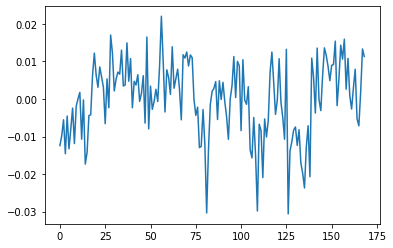

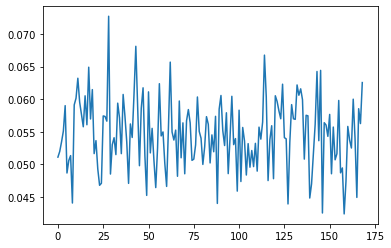

In [20]:
#Break each array into groups where 1 second has passed

# Reference start time
t0 = x1[0]

# Compute elapsed time in seconds from t0
elapsed = x1 - t0

#(0.169s) (~0.25 ns)

# Group index based on how many full seconds have passed
group_ids = np.floor(elapsed).astype(int)

# Split into groups
time_groups = [x1[group_ids == g] for g in np.unique(group_ids)]

print("Total Seconds Sampled:", len(time_groups))
print("Samples per Second:", len(time_groups[0]))

c1_resid_groups = [resid1[group_ids == g] for g in np.unique(group_ids)]

c1_drifts = np.array([np.mean(g) for g in c1_resid_groups]) 

c1_drift = np.std(c1_drifts)

print("Clock 1 Drift (s):", c1_drift*1e-9)

c1_jitters = np.array([np.std(g) for g in c1_resid_groups])

c1_jitter = np.mean(c1_jitters)

print("Clock 1 Jitter (s):", c1_jitter*1e-9)

plt.figure()
plt.plot(c1_drifts)

plt.figure()
plt.plot(c1_jitters)


0.0199987200000038
Total Seconds Sampled:  169
Samples per Second:  51
Clock 2 Drift (s):  1.356791501081506e-09
Clock 2 Jitter (s):  6.05777131820888e-11


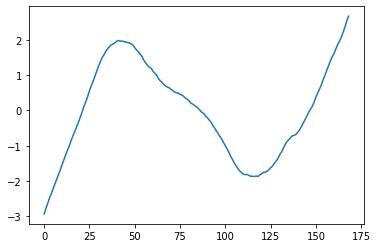

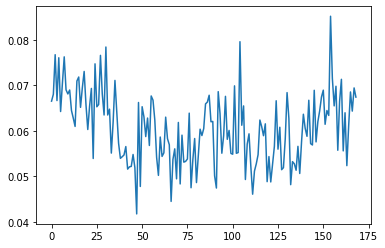

In [11]:
#Break each array into groups where 1 second has passed

# Reference start time
t0 = x2[0]

# Compute elapsed time in seconds from t0
elapsed = x2 - t0

print(x2[1]-x2[0])

# Group index based on how many full seconds have passed
group_ids = np.floor(elapsed).astype(int)

# Split into groups
time_groups = [x2[group_ids == g] for g in np.unique(group_ids)]

print("Total Seconds Sampled: ", len(time_groups))
print("Samples per Second: ", len(time_groups[0]))

c2_resid_groups = [resid2[group_ids == g] for g in np.unique(group_ids)]

c2_drifts = np.array([np.mean(g) for g in c2_resid_groups]) 

c2_drift = np.std(c2_drifts)

print("Clock 2 Drift (s): ", c2_drift*1e-9)

c2_jitters = np.array([np.std(g) for g in c2_resid_groups])

c2_jitter = np.mean(c2_jitters)

print("Clock 2 Jitter (s): ", c2_jitter*1e-9)

plt.figure()
plt.plot(c2_drifts)

plt.figure()
plt.plot(c2_jitters)